# TF-IDF and Logistic Regression Baseline

This notebook explains the traditional baseline used to compare with
DistilBERT. The complete reusable implementation is in `src/baseline.py`.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.baseline import run_baseline
from src.config import FIGURE_DIR, METRICS_DIR

## 1. Why use a baseline?

A baseline answers an important question: does the Transformer improve on a
simpler method? TF-IDF measures how informative words and two-word phrases are,
and Logistic Regression learns four decision boundaries from those features.

In [2]:
RUN_BASELINE = False

if RUN_BASELINE:
    baseline_results = run_baseline(max_features=30_000)
else:
    metrics_path = METRICS_DIR / 'baseline_metrics.json'
    if not metrics_path.exists():
        raise FileNotFoundError('Run: python -m src.baseline')
    with open(metrics_path, encoding='utf-8') as file:
        baseline_results = json.load(file)

display(pd.DataFrame([
    {'split': split_name, **baseline_results[split_name]}
    for split_name in ['validation', 'test']
]).round(4))

,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,validation,0.9195,0.9194,0.9195,0.9193,0.9193
1,test,0.9183,0.9181,0.9183,0.9181,0.9181


## 2. Baseline configuration

- Unigrams and bigrams
- Maximum of 30,000 TF-IDF features
- Terms appearing in fewer than two documents are removed
- Very common terms appearing in more than 95% of documents are removed
- English stop words are removed for this traditional model
- Logistic Regression is trained only on the training split

The Transformer preprocessing is different: DistilBERT keeps stop words and
natural sentence order.

,precision,recall,f1-score,support
World,0.9317,0.9116,0.9215,1900.0000
Sports,0.9549,0.9805,0.9675,1900.0000
Business,0.8920,0.8821,0.8870,1900.0000
Sci/Tech,0.8938,0.8989,0.8964,1900.0000
accuracy,0.9183,0.9183,0.9183,0.9183
macro avg,0.9181,0.9183,0.9181,7600.0000
weighted avg,0.9181,0.9183,0.9181,7600.0000


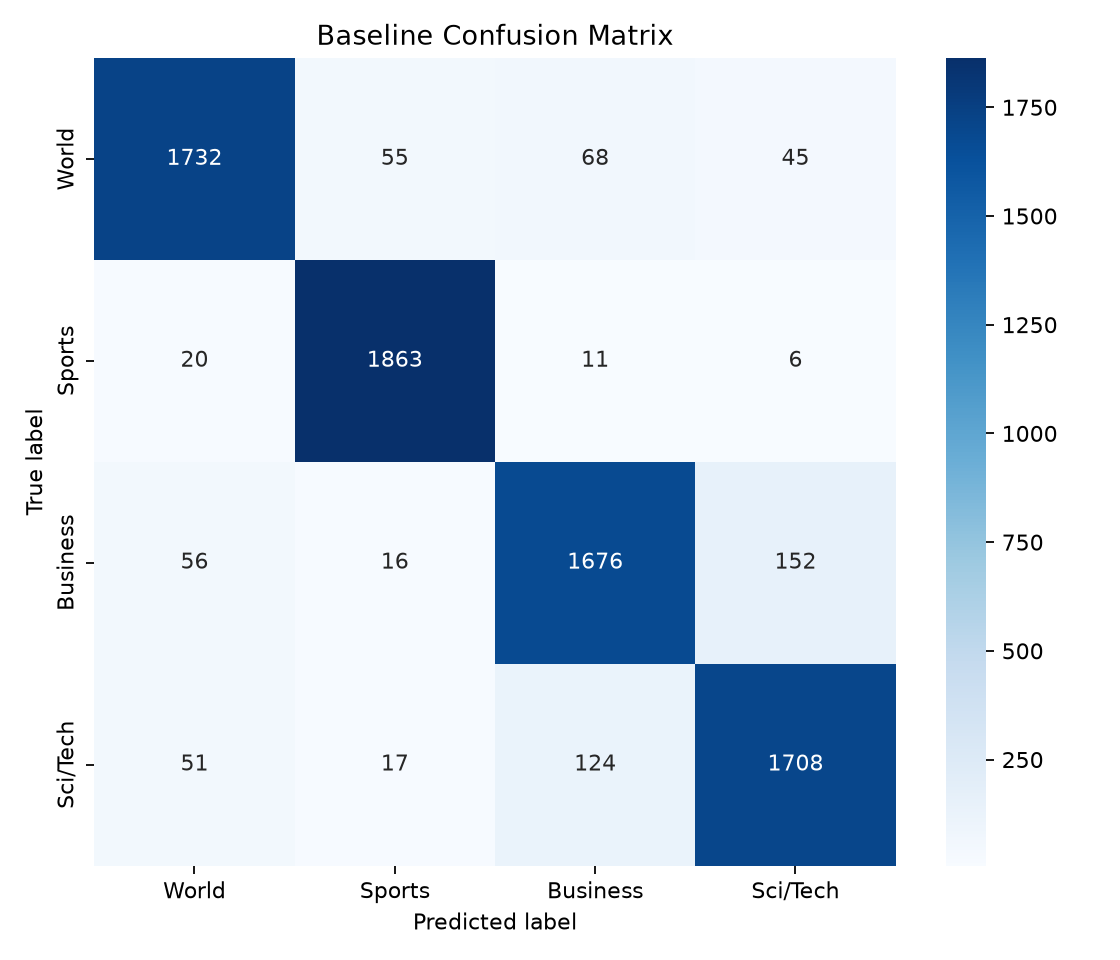

In [3]:
report_path = METRICS_DIR / 'baseline_report.csv'
if report_path.exists():
    display(pd.read_csv(report_path, index_col=0).round(4))

matrix_path = FIGURE_DIR / 'baseline_confusion_matrix.png'
if matrix_path.exists():
    display(Image(filename=str(matrix_path)))

## 3. Baseline interpretation

The TF-IDF and Logistic Regression baseline achieved **91.83% test accuracy**
and **91.81% macro F1**. Sports had the highest recall at **98.05%**, while
Business and Sci/Tech were more frequently confused because their vocabulary
often overlaps.

This is a strong result for a traditional model and provides a meaningful
comparison for evaluating whether DistilBERT’s additional training cost is
worthwhile. The saved TF-IDF vectorizer and Logistic Regression model are
stored in `models/baseline/`.